# 5장 2강: 어텐션 메커니즘 도입
## 3. 파이토치 기반 실습 및 가중치 시각화

### 3.2 데이터 가공 및 가상 연산 코드 작성

In [1]:
import platform
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# OS별 한글 폰트 설정 (깨짐 방지)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

# 소스 문장(영어)과 타깃 문장(한국어) 단어 목록 선언
src_words = ["i", "love", "ml"]
tgt_words = ["나는", "머신러닝을", "사랑한다"]

# 4차원 임베딩 공간을 가정한 가상의 벡터 정의
# Query: 한국어 번역 단어들의 상태 벡터
# 처음이니까 랜덤하게 들어갑니다~ / 임베딩
Q = torch.tensor([
    [1.5, 0.1, 0.0, 0.2],    # '나는' 예측을 위한 Query
    [0.1, 0.2, 1.8, 0.5],    # '머신러닝을' 예측을 위한 Query
    [0.2, 1.7, 0.1, -0.1]    # '사랑한다' 예측을 위한 Query
], dtype=torch.float32)

# Key: 영어 입력 단어들의 이름표 벡터
# 처음이니까 여기도 랜덤하게 들어갑니다~ / 임베딩
K = torch.tensor([
    [1.4, 0.2, 0.1, 0.1],    # 'i'에 해당하는 Key
    [0.1, 1.6, 0.2, 0.0],    # 'love'에 해당하는 Key
    [0.0, 0.1, 1.9, 0.4]     # 'ml'에 해당하는 Key
], dtype=torch.float32)

# Value: 각 단어의 실제 의미 정보를 담은 벡터 (Key와 동일하게 설정)
# Q,K 값에 가중치 적용~
V = K.clone()

# 1단계: 유사도 스코어 계산 (행렬 곱셈, 내적, Dot Product)
# 두 벡터의 상응하는 성분들을 곱한 뒤 모두 더하는 연산으로, 모델 내부에서 두 단어 벡터 간의 유사도를 측정할 때 사용됩니다.
scores = torch.matmul(Q, K.t())

# 2단계: 소프트맥스 함수를 통해 가중치 합이 1이 되도록 정규화
attention_weights = F.softmax(scores, dim=-1)

# 3단계: 가중치와 Value를 곱하고 합산하여 컨텍스트 벡터 도출
context_vectors = torch.matmul(attention_weights, V)

### 3.3 가중치 히트맵 시각화 결과 분석

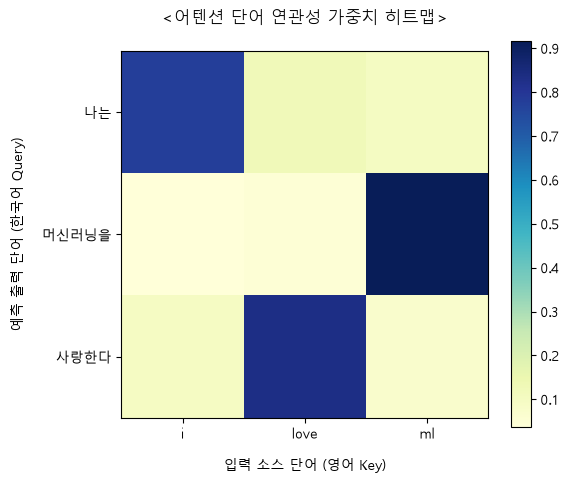

In [2]:
# NumPy 배열로 변환
weights_np = attention_weights.detach().numpy()

# 그래프 생성 및 컬러맵 적용
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(weights_np, cmap='YlGnBu') # 연한 노란색에서 짙은 파란색으로 표현
fig.colorbar(cax) 

# 축 레이블 설정
ax.set_xticks(np.arange(len(src_words)))
ax.set_yticks(np.arange(len(tgt_words)))
ax.set_xticklabels(src_words)
ax.set_yticklabels(tgt_words)

# 10. 세부 정렬 설정
ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)
plt.xlabel("입력 소스 단어 (영어 Key)", labelpad=12)
plt.ylabel("예측 출력 단어 (한국어 Query)", labelpad=12)
plt.title("<어텐션 단어 연관성 가중치 히트맵>", pad=20)

plt.tight_layout()
plt.show()

- 히트맵형태
- 진한 컬러가 중요한 것